# Data Exploration and Analysis

This step isn't necessary, I just want to get an idea of what the data looks like as a fan of the sport. Modeling will be done in a separate notebook.

Here, we're just going to bring in our dataframe and take a look at the data to help decide what we want to look at. One thing that is important to note at this step is the UFC promotes the more popular "A-Side" fighter in the red corner. This will likely lead to statistical differences between red and blue corners, so they will be looked at independently in most cases.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None) 

In [2]:
df = pd.read_csv('../data/df.csv')

df.head()

,RedFighter,BlueFighter,RedOdds,BlueOdds,RedWinner,RedReturn,BlueReturn,OddsDiff,AgeDiff,ReachDiff,HeightDiff,WinsDiff,LossesDiff,RoundsDiff,WinStreakDiff,LoseStreakDiff,RankDiff,Date,TitleBout,WeightClass,Gender,NumberOfRounds,Finish,FinishRound,BlueCurrentLoseStreak,BlueCurrentWinStreak,BlueLongestWinStreak,BlueLosses,BlueTotalRoundsFought,BlueTotalTitleBouts,BlueWinsByKO,BlueWinsBySubmission,BlueWins,BlueStance,BlueHeightCms,BlueReachCms,BlueAge,BMatchWCRank,RedCurrentLoseStreak,RedCurrentWinStreak,RedLongestWinStreak,RedLosses,RedTotalRoundsFought,RedTotalTitleBouts,RedWinsByKO,RedWinsBySubmission,RedWins,RedStance,RedHeightCms,RedReachCms,RedAge,RMatchWCRank
0,Colby Covington,Joaquin Buckley,205,-250,False,0.0000,1.4000,455,6,-10.16,2.54,2,0,24,-5,1,-3,2024-12-14,False,Welterweight,MALE,5,KO/TKO,3,0,5,5,4,34,0,7,0,10,Southpaw,177.80,193.04,30,9,1,0,7,4,58,4,3,2,12,Orthodox,180.34,182.88,36,6
1,Cub Swanson,Billy Quarantillo,124,-148,True,2.2400,0.0000,272,5,0.00,-5.08,12,9,54,0,0,0,2024-12-14,False,Featherweight,MALE,3,KO/TKO,3,1,0,4,4,28,0,4,1,7,Orthodox,177.80,177.80,36,20,1,0,6,13,82,0,6,2,19,Orthodox,172.72,177.80,41,20
2,Manel Kape,Bruno Silva,-395,310,True,1.2532,0.0000,-705,-3,7.62,2.54,0,1,1,-4,1,-3,2024-12-14,False,Flyweight,MALE,3,KO/TKO,3,0,4,4,2,16,0,3,1,4,Orthodox,162.56,165.10,34,12,1,0,4,3,17,0,2,0,4,Southpaw,165.10,172.72,31,9
3,Vitor Petrino,Dustin Jacoby,-340,270,False,0.0000,3.7000,-610,-9,2.54,-2.54,-3,-5,-21,0,-1,0,2024-12-14,False,Light Heavyweight,MALE,3,KO/TKO,3,2,0,4,6,35,0,4,0,8,Orthodox,190.50,193.04,36,20,1,0,5,1,14,0,2,1,5,Orthodox,187.96,195.58,27,20
4,Adrian Yanez,Daniel Marcos,185,-225,False,0.0000,1.4444,410,0,2.54,0.00,3,2,2,-3,0,0,2024-12-14,False,Bantamweight,MALE,3,S-DEC,3,0,4,4,0,13,0,1,0,4,Orthodox,170.18,175.26,31,20,0,1,6,2,15,0,6,0,7,Orthodox,170.18,177.80,31,20


## 1. Fight Odds

Let's take a look at the average return on each column to see what we're working with.

In [3]:
avgRed = round(df['RedReturn'].mean(), 4)
avgBlue = round(df['BlueReturn'].mean(), 4)

print("All red bets will change your money by a factor of " + str(avgRed) + " while all blue bets would see a factor of " + str(avgBlue))

All red bets will change your money by a factor of 1.0041 while all blue bets would see a factor of 0.8965


All red bets would have seen an increase of .41% of money bet, while all blue bets would've decreased your money by over 10%. That difference is how the house always wins, and that's what we're trying to beat. Let's take a look at the odds for red and blue, discounting extreme outliers of odds exceeding -1000 or +800

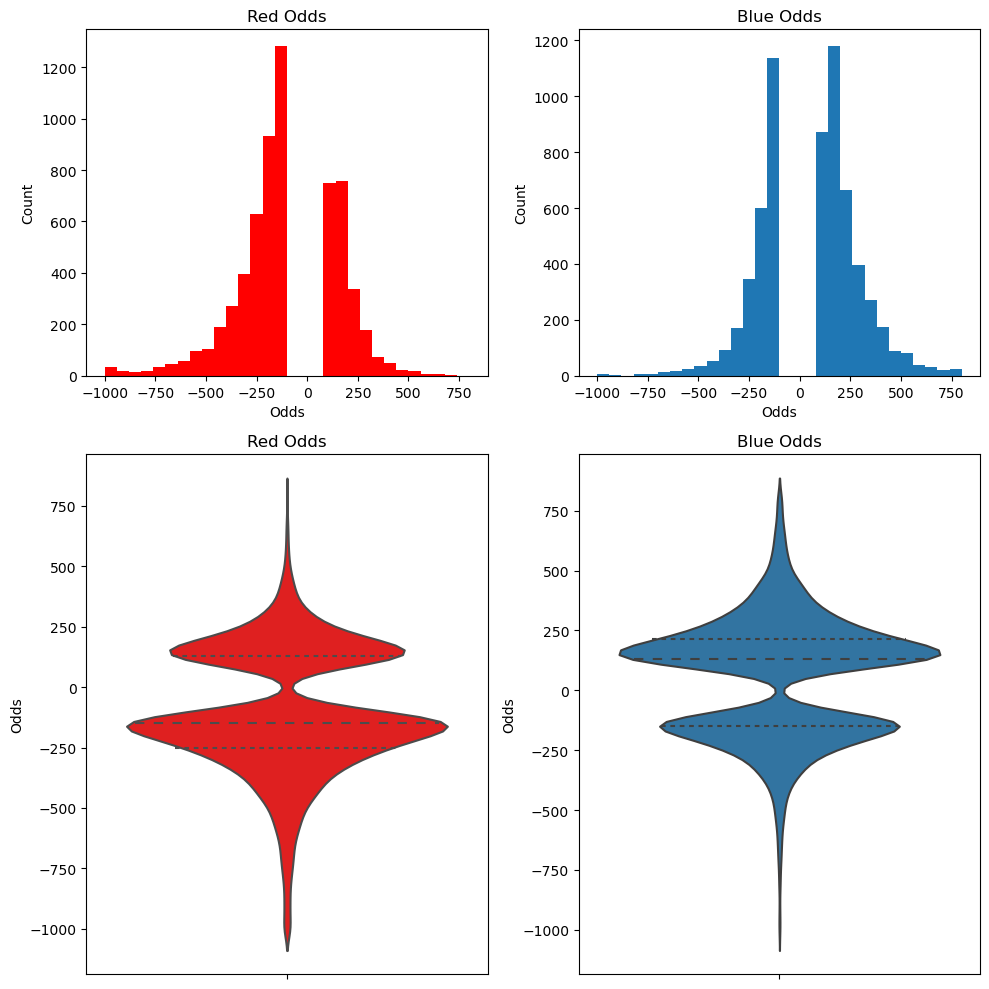

In [4]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(10, 10), gridspec_kw={'height_ratios': [1, 1.5]})

ax1.hist(df.RedOdds, bins=30, range = (-1000, 800), color='Red')
ax1.set_xlabel('Odds')
ax1.set_ylabel('Count')
ax1.set_title('Red Odds')

ax2.hist(df.BlueOdds, bins=30, range = (-1000, 800))
ax2.set_xlabel('Odds')
ax2.set_ylabel('Count')
ax2.set_title('Blue Odds')

sns.violinplot(data=df[df['RedOdds'].between(-1000, 800)], y='RedOdds', color='red', inner='quartile', ax=ax3)
ax3.set_ylabel('Odds')
ax3.set_title('Red Odds')

sns.violinplot(data=df[df['BlueOdds'].between(-1000, 800)], y='BlueOdds', inner='quartile', ax=ax4)
ax4.set_ylabel('Odds')
ax4.set_title('Blue Odds')

plt.tight_layout()
plt.show()

The data here looks very similar, each with nothing below 100 on either side. We do see some more slight underdogs out of the blue corner and more slight favorites from the red. This teaches us that the A-side fighter is more likely to be favored as well.

Let's take a look at some big underdog winners from each corner.

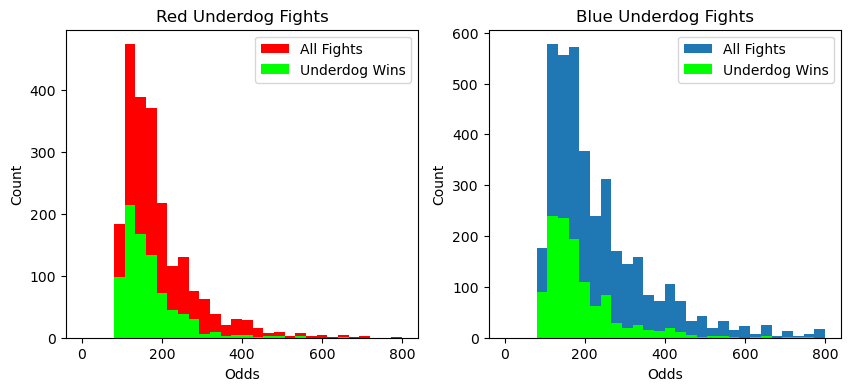

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.hist(df.RedOdds, bins=30, range = (0, 800), label = 'All Fights', color='Red')
ax1.hist(df.loc[df['RedWinner'] == True, 'RedOdds'], bins=30, range = (0, 800), label = 'Underdog Wins', color='lime')
ax1.set_xlabel('Odds')
ax1.set_ylabel('Count')
ax1.set_title('Red Underdog Fights')
ax1.legend()

ax2.hist(df.BlueOdds, bins=30, range = (0, 800), label = 'All Fights')
ax2.hist(df.loc[df['RedWinner'] == False, 'BlueOdds'], bins=30, range = (0, 800), label = 'Underdog Wins', color='lime')
ax2.set_xlabel('Odds')
ax2.set_ylabel('Count')
ax2.set_title('Blue Underdog Fights')
ax2.legend()

plt.show()

We can see here that as the odds get worse, the underdog is less likely to win. There are a couple of spikes around the +300 and +400 mark of the blue corner, as well as around 50% chance the underdog wins in the red corner for the first couple columns. Those are spots where I want my model to target and make its money. Let's take a look at the same kind of data, except this time from what the computer will see: odds difference vs result.

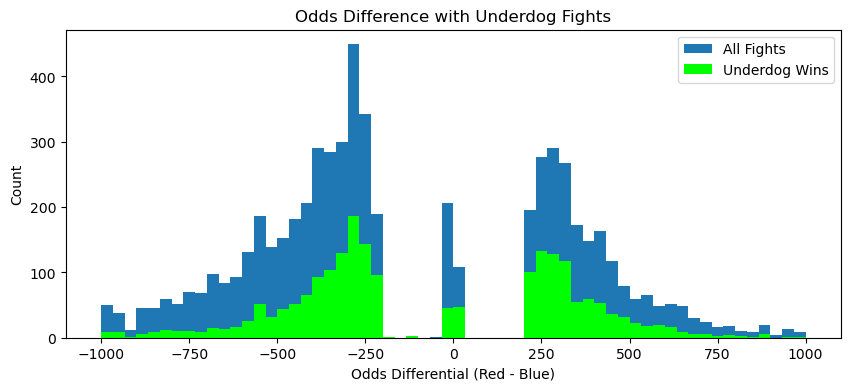

Red upset rate: 38.1711
Blue upset rate: 30.253
Total upset rate: 32.93122356258812


In [6]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(df['OddsDiff'], bins=60, range=(-1000, 1000), label='All Fights')

underdogWins = df[((df['RedWinner'] == True) & (df['OddsDiff'] > 0)) |
                   ((df['RedWinner'] == False) & (df['OddsDiff'] < 0))]

ax.hist(underdogWins['OddsDiff'], bins=60, range=(-1000, 1000), color='lime', label='Underdog Wins')

ax.set_xlabel('Odds Differential (Red - Blue)')
ax.set_ylabel('Count')
ax.set_title('Odds Difference with Underdog Fights')
ax.legend()

plt.show()

totalFights = len(df)
upsetWins = len(underdogWins)

upsetRate = (upsetWins / totalFights) * 100
redUnderdogFights  = df[df['RedOdds'] > 0]
blueUnderdogFights = df[df['BlueOdds'] > 0]
redUpsets  = len(redUnderdogFights[redUnderdogFights['RedWinner'] == True])
blueUpsets = len(blueUnderdogFights[blueUnderdogFights['RedWinner'] == False])
redUpsetRate = round((redUpsets / len(redUnderdogFights)) * 100, 4)
blueUpsetRate = round((blueUpsets / len(blueUnderdogFights)) * 100, 4)

print('Red upset rate: ' + str(redUpsetRate))
print('Blue upset rate: ' + str(blueUpsetRate))
print('Total upset rate: ' + str(upsetRate))

From this chart, things look really close on the right side. Since the odds differential is Red-Blue, The right side of the chart is showing us how often Red upsets Blue. We can also see from the data that red corner underdogs win over 38% of the time, but the red corner is less often the underdog. Our model's ability to find out why will be crucial to our success.

Since this is a potential money-making area, let's see what we would have made if we bet on every red-corner underdog.

In [7]:
avgRedUnderdog = round(df.loc[df['RedOdds'] > 0, 'RedReturn'].mean(), 4)
avgBlueUnderdog = round(df.loc[df['BlueOdds'] > 0, 'BlueReturn'].mean(), 4)

print(f'Betting on all red-corner underdogs would see your money increased by a factor of {avgRedUnderdog}, while all blue-corner underdogs would see a factor of {avgBlueUnderdog}')

Betting on all red-corner underdogs would see your money increased by a factor of 1.0218, while all blue-corner underdogs would see a factor of 0.8763


Interestingly, betting on only red-corner underdogs is 5x better than betting on only red-corner fighters, while betting on only blue-corner underdogs is about 2% worse.

## 2. Age

Combat sports are very hard on the body. Most fighters are in their prime until they're not, and once a losing streak starts the ball keeps on rolling. Each fighter is different and some age sooner than others due to quantity/severity of previous fights or the way they train. We want to try and pinpoint when a loss is one-off and when it is the start of a big losing streak. Let's see how losing streaks and age relate.

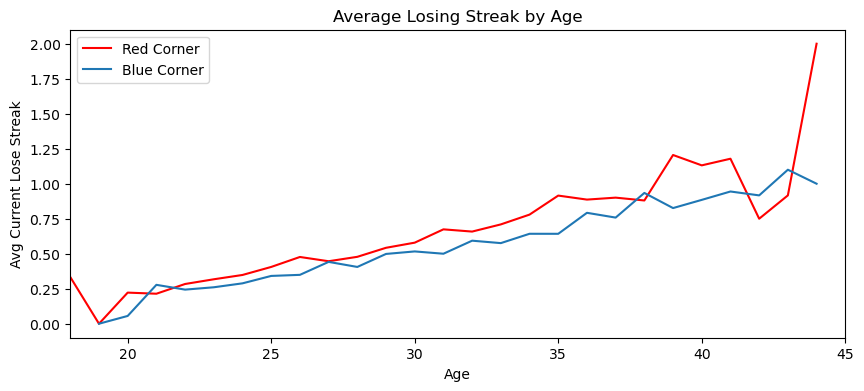

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))

ageRange = range(18, 45)

redAvgLoseStreak = [df[df['RedAge'] == age]['RedCurrentLoseStreak'].mean() for age in ageRange]
blueAvgLoseStreak = [df[df['BlueAge'] == age]['BlueCurrentLoseStreak'].mean() for age in ageRange]

ax.plot(ageRange, redAvgLoseStreak, color='red', label='Red Corner')
ax.plot(ageRange, blueAvgLoseStreak, label='Blue Corner')

ax.set_xlabel('Age')
ax.set_ylabel('Avg Current Lose Streak')
ax.set_title('Average Losing Streak by Age')
ax.set_xlim(18, 45)
ax.legend()

plt.show()

Curiously, despite the red corner being the A-side, we tend to see red corner fighters on larger losing streaks than blue corner fighters. How about the same plot, but instead with winning streaks?

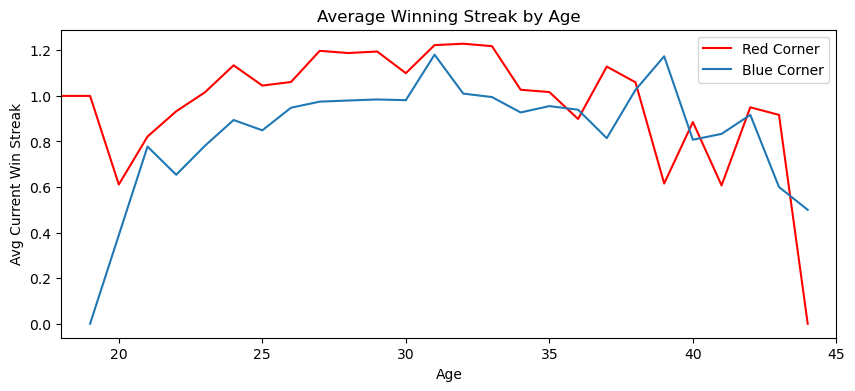

In [9]:
fig, ax = plt.subplots(figsize=(10, 4))

ageRange = range(18, 45)

redAvgWinStreak = [df[df['RedAge'] == age]['RedCurrentWinStreak'].mean() for age in ageRange]
blueAvgWinStreak = [df[df['BlueAge'] == age]['BlueCurrentWinStreak'].mean() for age in ageRange]

ax.plot(ageRange, redAvgWinStreak, color='red', label='Red Corner')
ax.plot(ageRange, blueAvgWinStreak, label='Blue Corner')

ax.set_xlabel('Age')
ax.set_ylabel('Avg Current Win Streak')
ax.set_title('Average Winning Streak by Age')
ax.set_xlim(18, 45)
ax.legend()

plt.show()

We can see blue-corner fighters also seem to have smaller winning streaks than red corner fighters. Perhaps for the same reason as before, red corner fighters are champions or former champions with their winning streaks intact. We can see a potential pattern for our model to look at with this age/streak information. Let's try another related to age: just blatant winning.

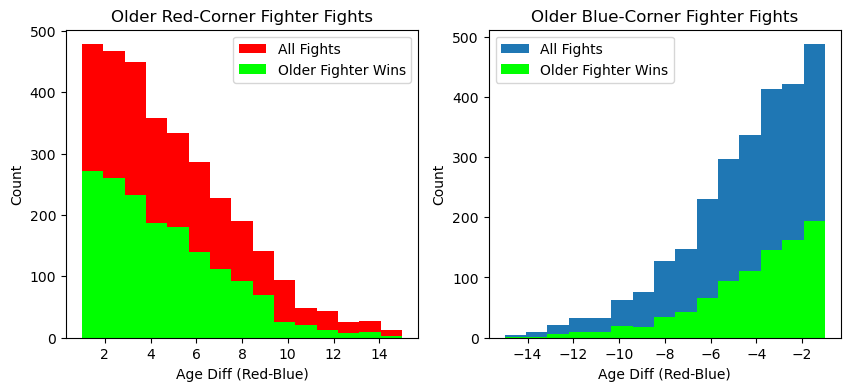

Older Red Fighter Win Rate: 50.9393
Older Blue Fighter Win Rate: 33.8393
Older Fighter Win Rate: 39.80886730377565


In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

dfRed = df[df['AgeDiff'] > 0]
dfBlue = df[df['AgeDiff'] < 0]

ax1.hist(dfRed.AgeDiff, bins=15, range = (1, 15), label = 'All Fights', color='Red')
ax1.hist(dfRed.loc[df['RedWinner'] == True, 'AgeDiff'], bins=15, range = (1, 15), label = 'Older Fighter Wins', color='lime')
ax1.set_xlabel('Age Diff (Red-Blue)')
ax1.set_ylabel('Count')
ax1.set_title('Older Red-Corner Fighter Fights')
ax1.legend()

ax2.hist(dfBlue.AgeDiff, bins=15, range = (-15, -1), label = 'All Fights')
ax2.hist(dfBlue.loc[df['RedWinner'] == False, 'AgeDiff'], bins=15, range = (-15, -1), label = 'Older Fighter Wins', color='lime')
ax2.set_xlabel('Age Diff (Red-Blue)')
ax2.set_ylabel('Count')
ax2.set_title('Older Blue-Corner Fighter Fights')
ax2.legend()

plt.show()

olderWins = df[((df['RedWinner'] == True) & (df['AgeDiff'] > 0)) |
                   ((df['RedWinner'] == False) & (df['AgeDiff'] < 0))]
totalFights = len(df)
olderFighterWins = len(olderWins)

olderWinRate = (olderFighterWins / totalFights) * 100
redOlderWins  = len(dfRed[dfRed['RedWinner'] == True])
blueOlderWins = len(dfBlue[dfBlue['RedWinner'] == False])
redOlderWinRate = round((redOlderWins / len(dfRed)) * 100, 4)
blueOlderWinRate = round((blueOlderWins / len(dfBlue)) * 100, 4)

print('Older Red Fighter Win Rate: ' + str(redOlderWinRate))
print('Older Blue Fighter Win Rate: ' + str(blueOlderWinRate))
print('Older Fighter Win Rate: ' + str(olderWinRate))

That red fighter number is right down the middle, but blue fighter has something totally different to say. Let's look at the returns for these.

In [11]:
avgRedOlder = round(df.loc[df['AgeDiff'] > 0, 'RedReturn'].mean(), 4)
avgBlueOlder = round(df.loc[df['AgeDiff'] < 0, 'BlueReturn'].mean(), 4)
avgRedYounger = round(df.loc[df['AgeDiff'] < 0, 'RedReturn'].mean(), 4)
avgBlueYounger = round(df.loc[df['AgeDiff'] > 0, 'BlueReturn'].mean(), 4)

print(f'Average Red Older Return: {avgRedOlder}')
print(f'Average Red Younger Return: {avgRedYounger}')
print(f'Average Blue Older Return: {avgBlueOlder}')
print(f'Average Blue Younger Return: {avgBlueYounger}')

Average Red Older Return: 0.966
Average Red Younger Return: 1.0435
Average Blue Older Return: 0.8243
Average Blue Younger Return: 0.9601


Betting on all younger red fighters is giving us our best factor yet: a 4.3% increase! This doesn't mean that if the red fighter is older, however, you go swinging for blue. Those odds will get you and you'll still lose to the house.

## 3. Streaks

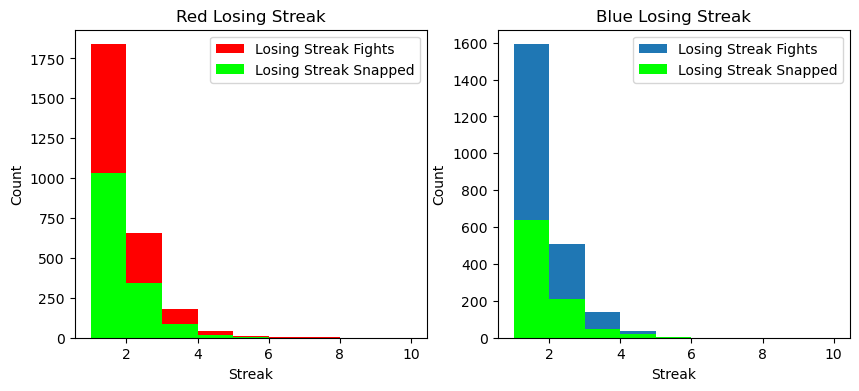

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.hist(df.RedCurrentLoseStreak, bins=9, range = (1, 10), label = 'Losing Streak Fights', color='Red')
ax1.hist(df.loc[df['RedWinner'] == True, 'RedCurrentLoseStreak'], bins=9, range = (1, 10), label = 'Losing Streak Snapped', color='lime')
ax1.set_xlabel('Streak')
ax1.set_ylabel('Count')
ax1.set_title('Red Losing Streak')
ax1.legend()

ax2.hist(df.BlueCurrentLoseStreak, bins=9, range = (1, 10), label = 'Losing Streak Fights')
ax2.hist(df.loc[df['RedWinner'] == False, 'BlueCurrentLoseStreak'], bins=9, range = (1,10), label = 'Losing Streak Snapped', color='lime')
ax2.set_xlabel('Streak')
ax2.set_ylabel('Count')
ax2.set_title('Blue Losing Streak')
ax2.legend()

plt.show()

Taking a look at this, we see red corner fighters on one fight losing streaks seem to win their next fight a little over half the time. Blue fighters on any kind of skid can't really seem to get it back.

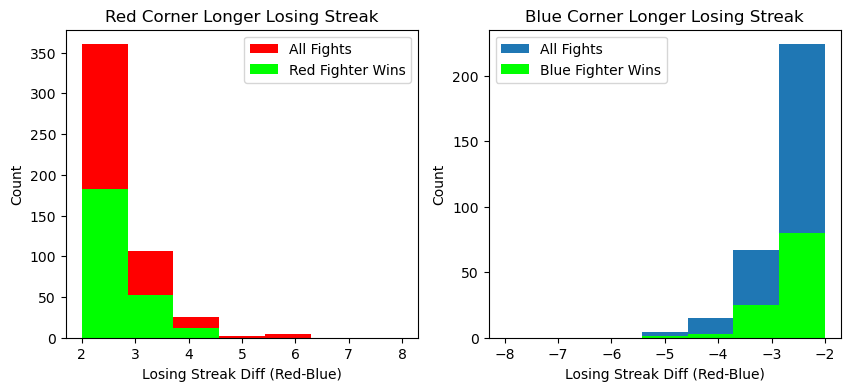

Bigger Red Loss Streak Win Rate: 51.8221
Bigger Blue Loss Streak Win Rate: 35.9066
Bigger Loss Streak Win Rate: 19.410935296882347


In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

dfRed = df[df['LoseStreakDiff'] > 0]
dfBlue = df[df['LoseStreakDiff'] < 0]

ax1.hist(dfRed.LoseStreakDiff, bins=7, range = (2, 8), label = 'All Fights', color='Red')
ax1.hist(dfRed.loc[df['RedWinner'] == True, 'LoseStreakDiff'], bins=7, range = (2, 8), label = 'Red Fighter Wins', color='lime')
ax1.set_xlabel('Losing Streak Diff (Red-Blue)')
ax1.set_ylabel('Count')
ax1.set_title('Red Corner Longer Losing Streak')
ax1.legend()

ax2.hist(dfBlue.LoseStreakDiff, bins=7, range = (-8, -2), label = 'All Fights')
ax2.hist(dfBlue.loc[df['RedWinner'] == False, 'LoseStreakDiff'], bins=7, range = (-8, -2), label = 'Blue Fighter Wins', color='lime')
ax2.set_xlabel('Losing Streak Diff (Red-Blue)')
ax2.set_ylabel('Count')
ax2.set_title('Blue Corner Longer Losing Streak')
ax2.legend()

plt.show()

biggerLoserWins = df[((df['RedWinner'] == True) & (df['LoseStreakDiff'] > 0)) |
                   ((df['RedWinner'] == False) & (df['LoseStreakDiff'] < 0))]
totalFights = len(df)
loserWins = len(biggerLoserWins)

loserWinRate = (loserWins / totalFights) * 100
redLoserWins  = len(dfRed[dfRed['RedWinner'] == True])
blueLoserWins = len(dfBlue[dfBlue['RedWinner'] == False])
redLoserWinRate = round((redLoserWins / len(dfRed)) * 100, 4)
blueLoserWinRate = round((blueLoserWins / len(dfBlue)) * 100, 4)

print('Bigger Red Loss Streak Win Rate: ' + str(redLoserWinRate))
print('Bigger Blue Loss Streak Win Rate: ' + str(blueLoserWinRate))
print('Bigger Loss Streak Win Rate: ' + str(loserWinRate))

That betting on a blue fighter on a 2+ fight skid seems like a terrible option. On the other hand, betting on a fighter on a bigger losing streak could get you good odds. Let's see how each of these return.

In [14]:
avgRedLStreak = round(df.loc[df['LoseStreakDiff'] > 1, 'RedReturn'].mean(), 4)
avgBlueLStreak = round(df.loc[df['LoseStreakDiff'] < 1, 'BlueReturn'].mean(), 4)

print(f'Longer Red Losing Streak Return: {avgRedLStreak}')
print(f'Longer Blue Losing Streak Return: {avgBlueLStreak}')

Longer Red Losing Streak Return: 0.9591
Longer Blue Losing Streak Return: 0.8838


Neither of these return profitable, which surprises me. Let's copy that code for winning streaks.

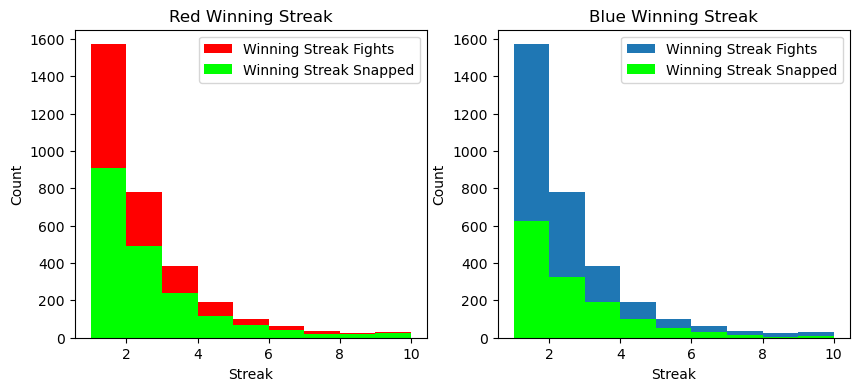

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.hist(df.RedCurrentWinStreak, bins=9, range = (1, 10), label = 'Winning Streak Fights', color='Red')
ax1.hist(df.loc[df['RedWinner'] == True, 'RedCurrentWinStreak'], bins=9, range = (1, 10), label = 'Winning Streak Snapped', color='lime')
ax1.set_xlabel('Streak')
ax1.set_ylabel('Count')
ax1.set_title('Red Winning Streak')
ax1.legend()

ax2.hist(df.RedCurrentWinStreak, bins=9, range = (1, 10), label = 'Winning Streak Fights')
ax2.hist(df.loc[df['RedWinner'] == False, 'BlueCurrentWinStreak'], bins=9, range = (1, 10), label = 'Winning Streak Snapped', color='lime')
ax2.set_xlabel('Streak')
ax2.set_ylabel('Count')
ax2.set_title('Blue Winning Streak')
ax2.legend()

plt.show()

It looks like streaking red fighters keep it up, but none of it matters without the odds. Let's look at the return.

In [16]:
avgRedStreaking = round(df.loc[df['RedCurrentWinStreak'] > 0, 'RedReturn'].mean(), 4)
avgBlueStreaking = round(df.loc[df['BlueCurrentWinStreak'] > 0, 'BlueReturn'].mean(), 4)

print(f'Average Streaking Red Return: {avgRedStreaking}')
print(f'Average Streaking Blue Return: {avgBlueStreaking}')

Average Streaking Red Return: 1.0149
Average Streaking Blue Return: 0.9313


Not the best results for us, but this is the best blue corner rate yet. Let's keep it going with streak differential.

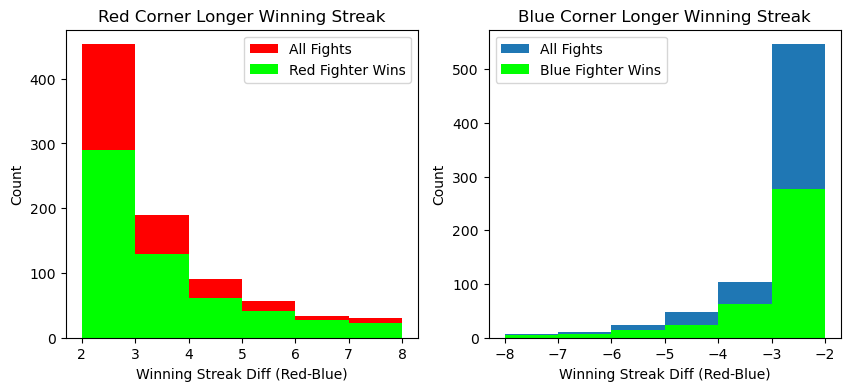

Bigger Red Win Streak Win Rate: 65.7447
Bigger Blue Win Streak Win Rate: 49.6978
Bigger Win Streak Win Rate: 58.652419115464525


In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

dfRed = df[df['WinStreakDiff'] > 0]
dfBlue = df[df['WinStreakDiff'] < 0]

ax1.hist(dfRed.WinStreakDiff, bins=6, range = (2, 8), label = 'All Fights', color='Red')
ax1.hist(dfRed.loc[df['RedWinner'] == True, 'WinStreakDiff'], bins=6, range = (2, 8), label = 'Red Fighter Wins', color='lime')
ax1.set_xlabel('Winning Streak Diff (Red-Blue)')
ax1.set_ylabel('Count')
ax1.set_title('Red Corner Longer Winning Streak')
ax1.legend()

ax2.hist(dfBlue.WinStreakDiff, bins=6, range = (-8, -2), label = 'All Fights')
ax2.hist(dfBlue.loc[df['RedWinner'] == False, 'WinStreakDiff'], bins=6, range = (-8, -2), label = 'Blue Fighter Wins', color='lime')
ax2.set_xlabel('Winning Streak Diff (Red-Blue)')
ax2.set_ylabel('Count')
ax2.set_title('Blue Corner Longer Winning Streak')
ax2.legend()

plt.show()

biggerWinnerWins = df[((df['RedWinner'] == True) & (df['WinStreakDiff'] > 0)) |
                   ((df['RedWinner'] == False) & (df['WinStreakDiff'] < 0))]
totalFights = len(df[df['WinStreakDiff'] != 0])
winnerWins = len(biggerWinnerWins)

winnerWinRate = (winnerWins / totalFights) * 100
redWinnerWins  = len(dfRed[dfRed['RedWinner'] == True])
blueWinnerWins = len(dfBlue[dfBlue['RedWinner'] == False])
redWinnerWinRate = round((redWinnerWins / len(dfRed)) * 100, 4)
blueWinnerWinRate = round((blueWinnerWins / len(dfBlue)) * 100, 4)

print(f'Bigger Red Win Streak Win Rate: {redWinnerWinRate}')
print(f'Bigger Blue Win Streak Win Rate: {blueWinnerWinRate}')
print(f'Bigger Win Streak Win Rate: {winnerWinRate}')

Again, we can see that the red corner fighter will be victorious more often. Let's do another check on the returns. 

In [18]:
avgRedWStreak = round(df.loc[df['WinStreakDiff'] > 0, 'RedReturn'].mean(), 4)
avgBlueWStreak = round(df.loc[df['WinStreakDiff'] < 0, 'BlueReturn'].mean(), 4)

print(f'Longer Red Winning Streak Return: {avgRedWStreak}')
print(f'Longer Blue Winning Streak Return: {avgBlueWStreak}')

Longer Red Winning Streak Return: 1.0286
Longer Blue Winning Streak Return: 0.9422


The house is looking tough here, not letting us get above a 3% increase very easily.

## 4. Size

One thing that cannot be ignored in fighting is size. Every fighter has tangibles that affect the way the fight will play out, from height and reach to simply their weight class. Let's get a good look at how height and reach are distributed across weight class.

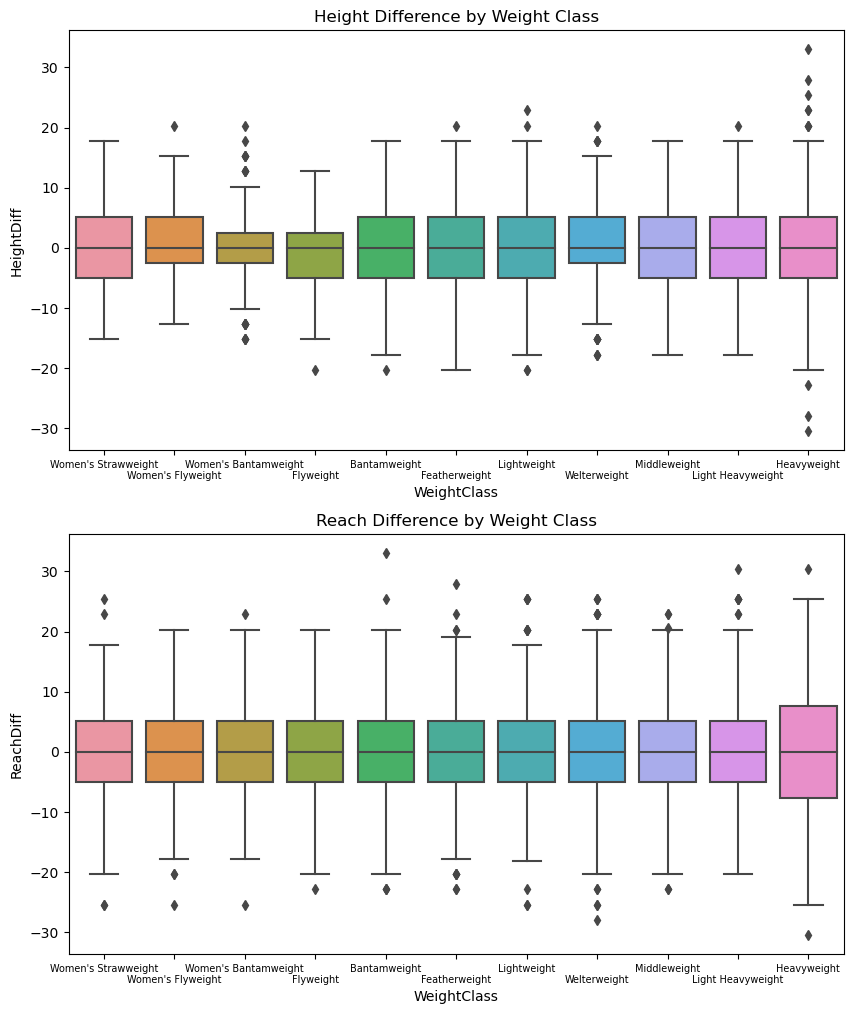

In [19]:
weightClassOrder = [
    "Women's Strawweight", "Women's Flyweight", "Women's Bantamweight", 'Flyweight', 'Bantamweight', 'Featherweight',
    'Lightweight', 'Welterweight', 'Middleweight', 'Light Heavyweight', 'Heavyweight'
]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12))

sns.boxplot(data=df, x="WeightClass", y="HeightDiff", order=weightClassOrder, ax=ax1)
sns.boxplot(data=df, x="WeightClass", y="ReachDiff", order=weightClassOrder, ax=ax2)

for ax in [ax1, ax2]:
    ax.set_xticks(ax.get_xticks())
    labels = ax.get_xticklabels()
    for i, label in enumerate(labels):
        label.set_fontsize(7)
        if i % 2 != 0:
            label.set_y(-0.025)
    ax.set_xticklabels(labels)
    
ax1.set_title('Height Difference by Weight Class')
ax2.set_title('Reach Difference by Weight Class')

plt.show()

Curiously, we see a larger reach discrepancy between some of the smaller male weight classes (flyweight and bantamweight) than we do in the ones diectly heavier (lightweight and welterweight). We also see welterweight has the smallest height range. The weight class that sees the most variance in height and reach is heavyweight. The abundance of outliers in the height plot and the length of the range in the reach plot tell the whole story there: height and reach play a big factor in those matchups. Also, women's height difference tend to get smaller as the weight increases, with outliers growing as well.

Let's take a look at some of the weight classes where the height and reach difference change a lot and see if that relates to outcomes.

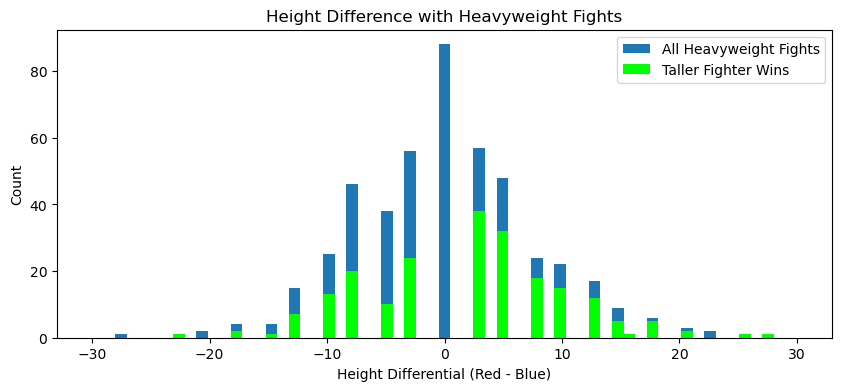

Red Tall Win Rate: 60.381
Blue Tall Win Rate: 42.8891
Tall Win Rate: 44.18604651162791


In [20]:
heavydf = df[df['WeightClass'] == 'Heavyweight'].copy()

fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(heavydf['HeightDiff'], bins=61, range=(-30, 30), label='All Heavyweight Fights')

tallWins = heavydf[((heavydf['RedWinner'] == True) & (heavydf['HeightDiff'] > 0)) |
                   ((heavydf['RedWinner'] == False) & (heavydf['HeightDiff'] < 0))]

ax.hist(tallWins['HeightDiff'], bins=61, range=(-30, 30), color='lime', label='Taller Fighter Wins')

ax.set_xlabel('Height Differential (Red - Blue)')
ax.set_ylabel('Count')
ax.set_title('Height Difference with Heavyweight Fights')
ax.legend()

plt.show()

totalFights = len(heavydf)

tallWinRate = (len(tallWins) / totalFights) * 100
redTallFights  = df[df['HeightDiff'] > 0]
blueTallFights = df[df['HeightDiff'] < 0]
redTallWins  = len(redTallFights[redTallFights['RedWinner'] == True])
blueTallWins = len(blueTallFights[blueTallFights['RedWinner'] == False])
redTallWinRate = round((redTallWins / len(redTallFights)) * 100, 4)
blueTallWinRate = round((blueTallWins / len(blueTallFights)) * 100, 4)

print('Red Tall Win Rate: ' + str(redTallWinRate))
print('Blue Tall Win Rate: ' + str(blueTallWinRate))
print('Tall Win Rate: ' + str(tallWinRate))

For some reason, it looks like when the taller heavyweight fighter is in the red corner, they win very often. Let's check the return on that.

In [21]:
avgRedTallWin = round(heavydf.loc[heavydf['HeightDiff'] > 0, 'RedReturn'].mean(), 4)

print(f'Taller Red Heavyweight Fighter Return: {avgRedTallWin}')

Taller Red Heavyweight Fighter Return: 1.1496


This is our biggest breakthrough yet! If you bet the same amount of money on the taller heavyweight for every heavyweight fight in this dataset, your money would increase by nearly 15%, regardless of any terrible odds you may have had.